In [55]:
# correlation between interest rates and the housing market
import matplotlib.pyplot as plt
import pandas as pd
from fredapi import Fred

# Get the current price of all S&P 500 stocks
import yfinance as yf

yf.pdr_override()

plt.ion()

FRED_API_KEY = "612c90fb30af12767bbcaf9513bac5ed"
fred = Fred(api_key=FRED_API_KEY)

In [56]:
fed_funds = fred.get_series("FEDFUNDS").dropna()

# Get the data for the S&P 500 from Yahoo Finance
sp = yf.Ticker("^GSPC").history(start="1980-01-01", interval="1mo")
sp.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1985-01-01 00:00:00-05:00,167.199997,180.270004,163.360001,179.630005,2673710000,0.0,0.0
1985-02-01 00:00:00-05:00,179.630005,183.949997,177.750000,181.179993,2194620000,0.0,0.0
1985-03-01 00:00:00-05:00,181.179993,183.889999,176.529999,180.660004,2153090000,0.0,0.0
1985-04-01 00:00:00-05:00,180.660004,183.610001,177.860001,179.830002,1981880000,0.0,0.0
1985-05-01 00:00:00-04:00,179.830002,189.979996,178.350006,189.550003,2350340000,0.0,0.0


In [57]:
# Change the date format to YYYY-MM-DD
sp.index = sp.index.to_series().apply(
    lambda x: pd.Timestamp(pd.Timestamp(x).strftime("%Y-%m-%d"))
)
sp

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1985-01-01,167.199997,180.270004,163.360001,179.630005,2673710000,0.0,0.0
1985-02-01,179.630005,183.949997,177.750000,181.179993,2194620000,0.0,0.0
1985-03-01,181.179993,183.889999,176.529999,180.660004,2153090000,0.0,0.0
1985-04-01,180.660004,183.610001,177.860001,179.830002,1981880000,0.0,0.0
1985-05-01,179.830002,189.979996,178.350006,189.550003,2350340000,0.0,0.0
...,...,...,...,...,...,...,...
2023-08-01,4578.830078,4584.620117,4335.310059,4507.660156,86840820000,0.0,0.0
2023-09-01,4530.600098,4541.250000,4238.629883,4288.049805,73482980000,0.0,0.0
2023-10-01,4284.520020,4393.569824,4103.779785,4193.799805,79952900000,0.0,0.0


In [58]:
# Make sure that both dataframes start and end at the same index
start_date = max(sp.index.min(), fed_funds.index.min())
end_date = min(sp.index.max(), fed_funds.index.max())

print(f"Start Date: {start_date}, End Date: {end_date}")

sp = sp.loc[start_date:end_date]
fed_funds = fed_funds.loc[start_date:end_date]

Start Date: 1985-01-01 00:00:00, End Date: 2023-11-01 00:00:00


In [59]:
df = sp["Close"].to_frame()
df

,Close
Date,
1985-01-01,179.630005
1985-02-01,181.179993
1985-03-01,180.660004
1985-04-01,179.830002
1985-05-01,189.550003
...,...
2023-07-01,4588.959961
2023-08-01,4507.660156
2023-09-01,4288.049805


In [60]:
df["FedFunds"] = fed_funds
df

,Close,FedFunds
Date,,
1985-01-01,179.630005,8.35
1985-02-01,181.179993,8.50
1985-03-01,180.660004,8.58
1985-04-01,179.830002,8.27
1985-05-01,189.550003,7.97
...,...,...
2023-07-01,4588.959961,5.12
2023-08-01,4507.660156,5.33
2023-09-01,4288.049805,5.33


In [61]:
x = df.iloc[:, :1]
y = df.iloc[:, 1]

x

,Close
Date,
1985-01-01,179.630005
1985-02-01,181.179993
1985-03-01,180.660004
1985-04-01,179.830002
1985-05-01,189.550003
...,...
2023-07-01,4588.959961
2023-08-01,4507.660156
2023-09-01,4288.049805


In [62]:
y = y.to_frame()
y

,FedFunds
Date,
1985-01-01,8.35
1985-02-01,8.50
1985-03-01,8.58
1985-04-01,8.27
1985-05-01,7.97
...,...
2023-07-01,5.12
2023-08-01,5.33
2023-09-01,5.33


In [63]:
# importing train_test_split from sklearn
from sklearn.model_selection import train_test_split

# splitting the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [64]:
# importing module
from sklearn.linear_model import LinearRegression

# creating an object of LinearRegression class
LR = LinearRegression()

# x_train = x_train.values.reshape(-1, 1)
# x_test = x_test.values.reshape(-1, 1)

# fitting the training data
LR.fit(x_train, y_train)

LinearRegression()

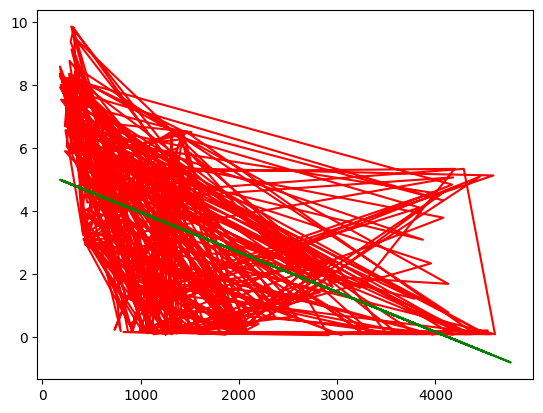

In [65]:
y_prediction = LR.predict(x_test)

plt.plot(x_train, y_train, color="red")
plt.plot(x_test, y_prediction, color="green")
plt.show()